#### ARTI 303 – Programming for AI (Assignment)
# Building a Basic Sentiment Analyzer with Python and TextBlob
____________________________________________________________________________________________


## Import Libraries

In [1]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
import os

### Task1:

Write a Python function called `sentimentAnalyzer(text)`. This function takes a text (i.e review) and returns the sentiment as follow:

- Score < -0.2: returns **‘Negative’**
- Score between -0.2 and 0.2: returns **‘Neutral’**
- Score > 0.2: returns **‘Positive’**

The score is the polarity of text as determined by TextBlob. An example of creating a textblob object is:

`blob = TextBlob(text)`

*(Refer to TextBlob’s documentation to learn about determining polarity)*


In [2]:
def sentimentAnalyzer(text):
    """
    Analyzes sentiment of text using TextBlob polarity score.
    
    Parameters:
    text (str): The text to analyze
    
    Returns:
    str: 'Positive', 'Negative', or 'Neutral' based on polarity score
    """
    blob = TextBlob(str(text))
    polarity = blob.sentiment.polarity # to get the sentiment score (between -1 and 1)
    
    if polarity < -0.2:
        return 'Negative'
    elif polarity > 0.2:
        return 'Positive'
    else:
        return 'Neutral'

### Task 2:
Verify that the function does classify the sentiment correctly by passing the following words to the function:


|   Word        | Polarity | Resulting Sentiment |
|:-------------:|:--------:|:-------------------:|
| happy         |   0.8    |      Positive       |
| exciting      |   0.3    |      Positive       |
| good          |   0.7    |      Positive       |
| rich          |  0.375   |      Positive       |
| smile         |   0.3    |      Positive       |
| sad           |  -0.5    |      Negative       |
| disappointed  | -0.75    |      Negative       |
| bad           | -0.699   |      Negative       |
| poor          |  -0.4    |      Negative       |
| anger         |  -0.7    |      Negative       |
| food          |   0      |      Neutral        |
| animal        |   0      |      Neutral        |

In [3]:
test_words = [
    ('happy', 0.8, 'Positive'),
    ('exciting', 0.3, 'Positive'),
    ('good', 0.7, 'Positive'),
    ('rich', 0.375, 'Positive'),
    ('smile', 0.3, 'Positive'),
    ('sad', -0.5, 'Negative'),
    ('disappointed', -0.75, 'Negative'),
    ('bad', -0.699, 'Negative'),
    ('poor', -0.4, 'Negative'),
    ('anger', -0.7, 'Negative'),
    ('food', 0, 'Neutral'),
    ('animal', 0, 'Neutral')
]

print("\nTest Results:")
print("-" * 80)
print(f"{'Word':<15} {'Polarity':<12} {'Expected':<15} {'Actual':<15} {'Status':<10}")
print("-" * 80)

for word, polarity, expected in test_words:
    actual = sentimentAnalyzer(word)
    status = "PASS" if actual == expected else "FAIL"
    print(f"{word:<15} {polarity:<12.3f} {expected:<15} {actual:<15} {status:<10}")

print("\n")


Test Results:
--------------------------------------------------------------------------------
Word            Polarity     Expected        Actual          Status    
--------------------------------------------------------------------------------
happy           0.800        Positive        Positive        PASS      
exciting        0.300        Positive        Positive        PASS      
good            0.700        Positive        Positive        PASS      
rich            0.375        Positive        Positive        PASS      
smile           0.300        Positive        Positive        PASS      
sad             -0.500       Negative        Negative        PASS      
disappointed    -0.750       Negative        Negative        PASS      
bad             -0.699       Negative        Negative        PASS      
poor            -0.400       Negative        Negative        PASS      
anger           -0.700       Negative        Negative        PASS      
food            0.000        Ne

### Task 3:
Import the provided dataset into a Pandas DataFrame. Filter the data to only include one product of your choice. The product you select must have at least 1000 reviews. Then, describe the data related to your product. This includes:

- Product name
- Number of rows
- Number of columns
- Length of the shortest review, length of the longest review, and the average length of the review. ‎

In [4]:
# Load the dataset
df = pd.read_csv('Amazon_Unlocked_Mobile.csv')

# Information about the dataset
print("\nOriginal dataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

# Check product distribution
print("\n\nProduct distribution:")
product_counts = df['Product Name'].value_counts()
print(product_counts.head(10))

# Find products with at least 1000 reviews
products_with_1000_plus = product_counts[product_counts >= 1000]
print(f"\n\nProducts with 1000+ reviews:")
for product, count in products_with_1000_plus.items():
    print(f"  - {product[:80]}... : {count} reviews")

# Select the first product with 1000+ reviews
if len(products_with_1000_plus) > 0:
    selected_product = products_with_1000_plus.index[0]
else:
    # If none have 1000+, select the product with most reviews
    selected_product = product_counts.index[0]

# Filter the dataset
df_filtered = df[df['Product Name'] == selected_product].copy()

print(f"\n\nSelected Product: {selected_product[:80]}...")
print(f"Number of rows: {len(df_filtered)}")
print(f"Number of columns: {len(df_filtered.columns)}")

# Calculate review length statistics
df_filtered['review_length'] = df_filtered['Reviews'].astype(str).apply(len)

shortest_review = df_filtered['review_length'].min()
longest_review = df_filtered['review_length'].max()
average_review = df_filtered['review_length'].mean()

print(f"\nReview Length Statistics:")
print(f"  - Shortest review: {shortest_review} characters")
print(f"  - Longest review: {longest_review} characters")
print(f"  - Average review length: {average_review:.2f} characters")

print("\n")


Original dataset shape: (413840, 6)

Column names: ['Product Name', 'Brand Name', 'Price', 'Rating', 'Reviews', 'Review Votes']

First few rows:
                                        Product Name Brand Name   Price  \
0  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
1  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
2  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
3  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
4  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   

   Rating                                            Reviews  Review Votes  
0       5  I feel so LUCKY to have found this used (phone...           1.0  
1       4  nice phone, nice up grade from my pantach revu...           0.0  
2       5                                       Very pleased           0.0  
3       4  It works good but it goes slow sometimes but i...           0.0  
4       4  Great p

### Task 4:
Apply the function sentimentAnalyzer(text)to the text column in your dataframe. This should create a new column in the dataframe called (Sentiment) which includes the sentiment for each review. 

In [5]:
print("=" * 80)
print("TASK 4: Applying Sentiment Analysis")
print("=" * 80)

# Apply the sentimentAnalyzer function to the Reviews column
df_filtered['Sentiment'] = df_filtered['Reviews'].apply(sentimentAnalyzer)

print(f"\nFirst 10 reviews with sentiment:")
print(df_filtered[['Product Name', 'Brand Name','Price', 'Reviews', 'Rating', 'Sentiment']].head(10))

# Calculate polarity for analysis
df_filtered['Polarity'] = df_filtered['Reviews'].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)

print("\n")

TASK 4: Applying Sentiment Analysis

First 10 reviews with sentiment:
                                            Product Name Brand Name  Price  \
16429  Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP...        NaN  99.99   
16430  Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP...        NaN  99.99   
16431  Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP...        NaN  99.99   
16432  Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP...        NaN  99.99   
16433  Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP...        NaN  99.99   
16434  Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP...        NaN  99.99   
16435  Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP...        NaN  99.99   
16436  Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP...        NaN  99.99   
16437  Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP...        NaN  99.99   
16438  Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP...        NaN  99.99   

                                                 Reviews  Rating Sentim

###### Edit the Brand Name from NaN to Apple

In [6]:
df_filtered['Brand Name'] = df_filtered['Brand Name'].fillna('Apple')
print(df_filtered.head(10))

                                            Product Name Brand Name  Price  \
16429  Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP...      Apple  99.99   
16430  Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP...      Apple  99.99   
16431  Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP...      Apple  99.99   
16432  Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP...      Apple  99.99   
16433  Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP...      Apple  99.99   
16434  Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP...      Apple  99.99   
16435  Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP...      Apple  99.99   
16436  Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP...      Apple  99.99   
16437  Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP...      Apple  99.99   
16438  Apple iPhone 4s 8GB Unlocked Smartphone w/ 8MP...      Apple  99.99   

       Rating                                            Reviews  \
16429       5                                           good buy   
16430

### Task 5:
Using visualization and summative statistics (in pandas and matlibplot), describe the results of the sentiment analysis of your product and analyze the results. This should include: 

- Visualizations of the results. For example, a bar chart showing number of documents with positive, negative, and neutral sentiment. Include any visualization you think is helpful. 
- Examples of reviews with positive, negative, and neural sentiment along with their polarity.
- Insights on what your client (producer or seller) need to do to minimize the negative sentiment and improve their reputation and product.
- Examples of reviews where you think TextBlob might have assigned the wrong sentiment to the review. Explain why you think this happened. Note: You may use the rating column to assess TextBlob’s sentiment. 

#### 5.1 Summary statistics

In [7]:
sentiment_counts = df_filtered['Sentiment'].value_counts()
sentiment_percentages = df_filtered['Sentiment'].value_counts(normalize=True) * 100

print("\nSentiment Distribution:")
print("-" * 50)
for sentiment in ['Positive', 'Neutral', 'Negative']:
    if sentiment in sentiment_counts.index:
        count = sentiment_counts[sentiment]
        percentage = sentiment_percentages[sentiment]
        print(f"{sentiment:<12}: {count:>5} reviews ({percentage:>5.1f}%)")


Sentiment Distribution:
--------------------------------------------------
Positive    :   768 reviews ( 52.9%)
Neutral     :   573 reviews ( 39.5%)
Negative    :   110 reviews (  7.6%)


#### 5.2 Create visualizations

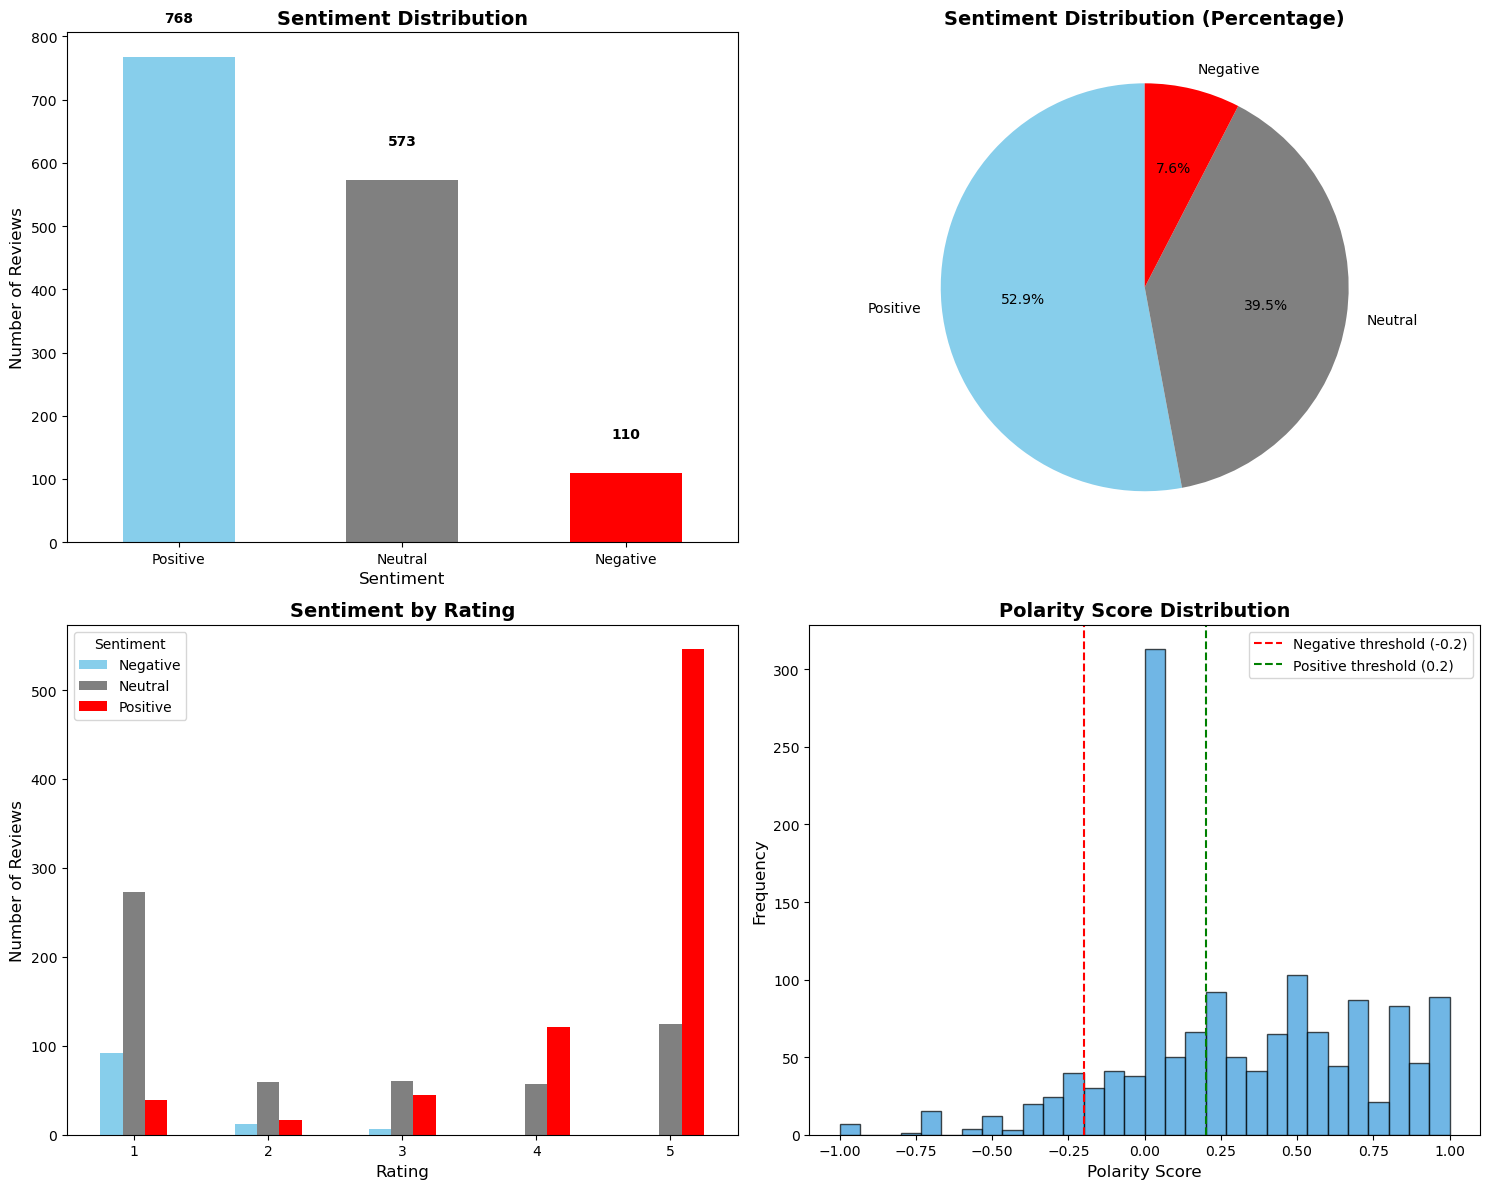

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Bar chart of sentiment distribution
ax1 = axes[0, 0]
sentiment_counts.plot(kind='bar', ax=ax1, color=['#87CEEB', 'gray', 'red'])
ax1.set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sentiment', fontsize=12)
ax1.set_ylabel('Number of Reviews', fontsize=12)
ax1.tick_params(axis='x', rotation=0)
for i, v in enumerate(sentiment_counts):
    ax1.text(i, v + 50, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Pie chart of sentiment distribution
ax2 = axes[0, 1]
colors = []
for sentiment in sentiment_counts.index:
    if sentiment == 'Positive':
        colors.append('#87CEEB')
    elif sentiment == 'Neutral':
        colors.append('gray')
    else:
        colors.append('red')

ax2.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
ax2.set_title('Sentiment Distribution (Percentage)', fontsize=14, fontweight='bold')

# 3. Rating vs Sentiment
ax3 = axes[1, 0]
sentiment_rating = df_filtered.groupby(['Rating', 'Sentiment']).size().unstack(fill_value=0)
sentiment_rating.plot(kind='bar', ax=ax3, stacked=False, 
                      color=['#87CEEB', 'gray', 'red'])
ax3.set_title('Sentiment by Rating', fontsize=14, fontweight='bold')
ax3.set_xlabel('Rating', fontsize=12)
ax3.set_ylabel('Number of Reviews', fontsize=12)
ax3.legend(title='Sentiment')
ax3.tick_params(axis='x', rotation=0)

# 4. Polarity distribution
ax4 = axes[1, 1]
ax4.hist(df_filtered['Polarity'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
ax4.axvline(x=-0.2, color='r', linestyle='--', label='Negative threshold (-0.2)')
ax4.axvline(x=0.2, color='g', linestyle='--', label='Positive threshold (0.2)')
ax4.set_title('Polarity Score Distribution', fontsize=14, fontweight='bold')
ax4.set_xlabel('Polarity Score', fontsize=12)
ax4.set_ylabel('Frequency', fontsize=12)
ax4.legend()

plt.tight_layout()

#### 5.3 Examples of reviews with different sentiments

In [9]:
print("\n" + "=" * 80)
print("SAMPLE REVIEWS BY SENTIMENT")
print("=" * 80)

for sentiment_type in ['Positive', 'Negative', 'Neutral']:
    print(f"\n{sentiment_type.upper()} REVIEWS:")
    print("-" * 80)
    
    sentiment_df = df_filtered[df_filtered['Sentiment'] == sentiment_type]
    if len(sentiment_df) > 0:
        samples = sentiment_df.nlargest(3, 'Polarity' if sentiment_type == 'Positive' 
                                       else 'Polarity' if sentiment_type == 'Negative'
                                       else 'review_length')
        
        for idx, row in samples.head(3).iterrows():
            print(f"\nRating: {row['Rating']}/5 | Polarity: {row['Polarity']:.3f}")
            review_text = str(row['Reviews'])[:200]
            print(f"Review: {review_text}{'...' if len(str(row['Reviews'])) > 200 else ''}")
    else:
        print(f"No {sentiment_type.lower()} reviews found.")


SAMPLE REVIEWS BY SENTIMENT

POSITIVE REVIEWS:
--------------------------------------------------------------------------------

Rating: 5/5 | Polarity: 1.000
Review: Great product!

Rating: 5/5 | Polarity: 1.000
Review: Works real good

Rating: 5/5 | Polarity: 1.000
Review: This iPgone was perfect for what I needed. Arrived in perfect condition, unlocked as said, and is working perfectly.

NEGATIVE REVIEWS:
--------------------------------------------------------------------------------

Rating: 1/5 | Polarity: -0.212
Review: This products comes with problems on the speakers, very bad sound quality. even can't hear the other person that is calling.

Rating: 1/5 | Polarity: -0.212
Review: This products comes with problems on the speakers, very bad sound quality. even can't hear the other person that is calling.

Rating: 1/5 | Polarity: -0.220
Review: Bad battery, bad charging dock, bad mic. Not "refurbished" piece of junk. Amozon is great and they issued refund fast. Thank you Amozon


#### 5.4 Insights and recommendations 

In [10]:
print("\n" + "=" * 80)
print("INSIGHTS AND RECOMMENDATIONS")
print("=" * 80)

positive_pct = sentiment_percentages.get('Positive', 0)
negative_pct = sentiment_percentages.get('Negative', 0)
neutral_pct = sentiment_percentages.get('Neutral', 0)

print(f"\n OVERALL SENTIMENT:")
print(f"   - {positive_pct:.1f}% of reviews are positive")
print(f"   - {negative_pct:.1f}% of reviews are negative")
print(f"   - {neutral_pct:.1f}% of reviews are neutral")

if positive_pct > 60:
    print("  The product has strong positive sentiment overall!")
elif negative_pct > 30:
    print("   Significant negative sentiment detected - immediate action needed!")


INSIGHTS AND RECOMMENDATIONS

 OVERALL SENTIMENT:
   - 52.9% of reviews are positive
   - 7.6% of reviews are negative
   - 39.5% of reviews are neutral


#### 5.5 Analyze negative reviews for common issues

In [11]:
print(f"\n Negative review analysis")
negative_reviews = df_filtered[df_filtered['Sentiment'] == 'Negative']['Reviews'].astype(str)
if len(negative_reviews) > 0:
    all_negative_text = ' '.join(negative_reviews.str.lower())
    
    common_negative_terms = [
        ('battery', 'Battery life issues'),
        ('broken', 'Product quality/defects'),
        ('charging', 'Charging problems'),
        ('not work', 'Functionality issues'),
        ('crack', 'Physical damage'),
        ('disappoint', 'General dissatisfaction'),
        ('return', 'Return/refund issues')
    ]
    
    print("   Common issues mentioned in negative reviews:")
    found_issues = []
    for term, description in common_negative_terms:
        if term in all_negative_text:
            count = all_negative_text.count(term)
            print(f"   - {description}: mentioned {count} times")
            found_issues.append(description)


 Negative review analysis
   Common issues mentioned in negative reviews:
   - Battery life issues: mentioned 26 times
   - Product quality/defects: mentioned 2 times
   - Charging problems: mentioned 3 times
   - Functionality issues: mentioned 7 times
   - General dissatisfaction: mentioned 21 times
   - Return/refund issues: mentioned 18 times


#### 5.6 Recommendation for the seller

In [12]:
print(f"\n RECOMMENDATIONS FOR THE SELLER:")
if negative_pct > 20:
    print("   HIGH PRIORITY ACTIONS:")
    print("   • Investigate and address the most common complaints immediately")
    print("   • Improve quality control before shipping products")
    print("   • Provide better product descriptions to set accurate expectations")

print("   IMPROVEMENT STRATEGIES:")
print("   • Respond to negative reviews professionally and offer solutions")
print("   • Consider offering warranties or better return policies")
print("   • Highlight positive aspects in marketing while addressing concerns")
print("   • Implement post-purchase follow-up to catch issues early")

if positive_pct > 50:
    print("   LEVERAGE POSITIVE FEEDBACK:")
    print("   • Feature positive reviews in marketing materials")
    print("   • Identify what customers love and emphasize those features")


 RECOMMENDATIONS FOR THE SELLER:
   IMPROVEMENT STRATEGIES:
   • Respond to negative reviews professionally and offer solutions
   • Consider offering warranties or better return policies
   • Highlight positive aspects in marketing while addressing concerns
   • Implement post-purchase follow-up to catch issues early
   LEVERAGE POSITIVE FEEDBACK:
   • Feature positive reviews in marketing materials
   • Identify what customers love and emphasize those features


#### 5.7 Potential misclassification analysis

In [13]:
print(f"\n Potential TextBlob Miscalssfications:")
print("-" * 80)

misclassified = df_filtered[
    ((df_filtered['Rating'] <= 2) & (df_filtered['Sentiment'] == 'Positive')) |
    ((df_filtered['Rating'] >= 4) & (df_filtered['Sentiment'] == 'Negative'))
]

if len(misclassified) > 0:
    print(f"\nFound {len(misclassified)} potential misclassifications:")
    print("\nExamples where TextBlob might have assigned wrong sentiment:")
    
    for idx, row in misclassified.head(5).iterrows():
        print(f"\n  Rating: {row['Rating']}/5 | Assigned: {row['Sentiment']} | Polarity: {row['Polarity']:.3f}")
        review_text = str(row['Reviews'])[:200]
        print(f"  Review: {review_text}{'...' if len(str(row['Reviews'])) > 200 else ''}")
        
        # why misclassification might have occurred
        if row['Rating'] <= 2 and row['Sentiment'] == 'Positive':
            print("  Possible reason: Review may contain positive words but overall context is negative")
        elif row['Rating'] >= 4 and row['Sentiment'] == 'Negative':
            print("  Possible reason: Review may mention problems but still rates highly (mixed review)")
else:
    print("\nNo obvious misclassifications detected based on rating/sentiment mismatch.")

print("\n" + "=" * 80)


 Potential TextBlob Miscalssfications:
--------------------------------------------------------------------------------

Found 56 potential misclassifications:

Examples where TextBlob might have assigned wrong sentiment:

  Rating: 1/5 | Assigned: Positive | Polarity: 0.250
  Review: The Battery is not lasting for more than two hours
  Possible reason: Review may contain positive words but overall context is negative

  Rating: 1/5 | Assigned: Positive | Polarity: 0.223
  Review: It is not unlocked, i love my virgin mobile iphone and it took a dive the last week so i got this as a replacement because in the details it said it was both gms and cdmc compatible. It is locked into...
  Possible reason: Review may contain positive words but overall context is negative

  Rating: 2/5 | Assigned: Positive | Polarity: 0.425
  Review: The information for this item said it was BSM unlocked and would work with Tmobile.It did NOT! So I asked for and was able to get a full refund.
  Possible reas

### Task 6
Export the dataframe to a csv file. 

In [14]:
output_file = 'sentiment_analysis_results.csv'
df_filtered.to_csv(output_file, index=False)

print(f"\n DataFrame exported successfully to: {output_file}")
print(f"  Total rows: {len(df_filtered)}")
print(f"  Total columns: {len(df_filtered.columns)}")


 DataFrame exported successfully to: sentiment_analysis_results.csv
  Total rows: 1451
  Total columns: 9


### Task 7
Write a technical report explaining the problem and outlining your results. Your ‎report should have the following:‎

- Title page
- Introduction
- Problem statement
- AI Solution
- Use case (the product you selected with the analysis results)‎
- Alignment between AI solution and client’s needs*‎
- Conclusion

* Your report must include a section which explains how the intelligent solution aligns with the client’s needs and requirements that are specified in the instructions (this document).


## Assessment Deadline:
The assignment is due: Thursday, December 4th , 2025.
## Assessment Deliverables:
You need to submit the complete notebook, your csv file (task 6), and assessment report.


@ 2025